# Discrete ambiguity in the $\alpha$ + $^{48}$Ca optical potential

This is the final notebook in a series of three: the [quickstart](./quickstart.ipynb) introduced the reaction and a least-squares fit, and [`alpha_ca_calibration.ipynb`](./alpha_ca_calibration.ipynb) performed a full Bayesian calibration of $\alpha$ + $^{40,44,48}$Ca elastic scattering at 29 MeV ([Oeschler, 1972](https://journals.aps.org/prl/abstract/10.1103/PhysRevLett.28.694)). We reuse its entire setup - the same data, potential form, error model and likelihood - without repeating the derivations; see that notebook for all of the details.

In the calibration we found that a moderately wide prior on the real depth $V$ for $^{48}$Ca admits more than one discrete solution, and we deliberately tightened the prior to select a single family. Here we do the opposite: we widen the prior on every potential parameter to loose physical bounds and let nested sampling map out however many discrete families the data support. This is the famous *discrete ambiguity* of light-ion optical potentials: depths differing by tens of MeV - interior wavefunctions with different numbers of nodes - can produce nearly identical elastic cross sections, so the likelihood surface carries a chain of well separated modes.

At the end we ask how the conclusions of the calibration notebook hold up: is the family we selected there the one the data prefer, and do the quantities we compared between isotopes survive marginalization over the ambiguity?

We do not need the sharp $\beta = 1$ posterior for that - only a map of where the families are and roughly how they compare. So we *temper* the likelihood: we sample $\pi(\theta)\, L(\theta)^{\beta}$ with $\beta = 1/T \ll 1$. Raising the likelihood to a small power does not move its peaks, so every family stays exactly where it is; it just broadens each basin and flattens the weights between them, which makes the multimodal landscape vastly cheaper to explore. The result is a survey of the discrete ambiguity that runs in a few minutes rather than hours.

In [1]:
# keep every process single-threaded: we will parallelize over likelihood
# evaluations with multiprocessing below, and nested BLAS/numba threads would
# oversubscribe the CPU. Must be set before numpy/jitr are imported.
import os

for var in ("OMP_NUM_THREADS", "OPENBLAS_NUM_THREADS", "MKL_NUM_THREADS", "NUMBA_NUM_THREADS"):
    os.environ.setdefault(var, "1")

# JITR_QUICK=1 runs a cut-down version of the notebook (fewer data points and live points) for CI
QUICK = os.environ.get("JITR_QUICK", "0") == "1"

import numpy as np
import pandas as pd
from matplotlib import pyplot as plt
from scipy import stats

## Set up the reaction, data and solver

Exactly as in the calibration notebook, restricted to $^{48}$Ca.

In [2]:
from jitr.reactions.reaction import Reaction

targets = {"Ca48": (48, 20)}
alpha = (4, 2)
reactions = {
    key: Reaction(target=target, projectile=alpha, process="El")
    for key, target in targets.items()
}

# calculate kinematics for a given lab energy
energy_lab = 29
kinematics = {key: reaction.kinematics(energy_lab) for key, reaction in reactions.items()}

In [3]:
df = pd.read_csv("./alpha_ca_ratio_ruth.csv")
df = df[df["target"] == "Ca48"]
if QUICK:
    df = df.iloc[::4]
data = {
    key: {"x": group["angle_cm_deg"].to_numpy(), "y": group["ratio_to_rutherford"].to_numpy()}
    for key, group in df.groupby("target")
}
colors = {"Ca48": "#FF9900"}
isotope_label = {key: rf"$^{{{A}}}$Ca" for key, (A, Z) in targets.items()}

In [4]:
from jitr.rmatrix import Solver as SolverKernel
from jitr.utils import utils
from jitr.xs import elastic

lmax = 60


def build_solver(key, angles_deg):
    A, Z = targets[key]
    interaction_range_fm = 1.2 * (A ** (1 / 3) + 4 ** (1 / 3)) + 2
    channel_radius_dimensionless = utils.suggested_dimensionless_channel_radius(
        interaction_range_fm, kinematics[key].k
    )
    channel_radius = channel_radius_dimensionless / kinematics[key].k
    N = utils.suggested_basis_size(channel_radius_dimensionless, zeros_per_node=8)
    print(f"Compiling solver for {reactions[key]} at {energy_lab} MeV: "
          f"channel radius {channel_radius:1.2f} fm, {N} nodes, {lmax} partial waves")
    return elastic.DifferentialWorkspace.build_from_system(
        reaction=reactions[key],
        kinematics=kinematics[key],
        channel_radius_fm=channel_radius,
        solver=SolverKernel(N),
        lmax=lmax,
        angles=np.deg2rad(angles_deg),
    )


solvers = {key: build_solver(key, data[key]["x"]) for key in targets}

Compiling solver for 48-Ca(alpha,el) at 29 MeV: channel radius 11.15 fm, 64 nodes, 60 partial waves


In [5]:
# jit warmup - do this before forking worker processes later so they inherit compiled code
for solver in solvers.values():
    _ = solver.xs(central_potential=np.zeros_like(solver.radial_grid()))

## The interaction

The same seven-parameter potential as the calibration notebook.

In [6]:
from jitr.optical_potentials.potential_forms import (
    coulomb_charged_sphere as coulomb,
    woods_saxon_safe as ws,
    woods_saxon_prime_safe as wsp,
)


def U_central(r, Vv, Wv, Ws, Rv, av, Rw, aw):
    return -Vv * ws(r, Rv, av) - 1j * Wv * ws(r, Rw, aw) - 1j * Ws * (-4 * aw) * wsp(r, Rw, aw)


def calculate_xs_ratio(theta, key):
    """Ratio to Rutherford on the data angles of `key` for optical model parameters `theta`."""
    solver = solvers[key]
    reaction = reactions[key]
    # each solver has its own radial quadrature grid (it depends on the channel radius)
    rgrid = solver.radial_grid()
    Vv, Wv, Ws, rv, av, rw, aw = theta
    A_factor = reaction.target.A ** (1 / 3)
    Zz = reaction.target.Z * reaction.projectile.Z
    xs = solver.xs(
        central_potential=U_central(rgrid, Vv, Wv, Ws, rv * A_factor, av, rw * A_factor, aw),
        coulomb_potential=coulomb(rgrid, Zz, 1.3 * A_factor),
    )
    return xs.dsdo / solver.rutherford


names = ["Vv", "Wv", "Ws", "rv", "av", "rw", "aw"]
labels = [r"$V$", r"$W_v$", r"$W_s$", r"$r_v$", r"$a_v$", r"$r_w$", r"$a_w$"]
n_omp = len(names)

## The error model and likelihood

Identical to [`alpha_ca_calibration.ipynb`](./alpha_ca_calibration.ipynb): a relative error $s$ uncorrelated from point to point plus a relative error $b$ common to all points, evaluated exactly in log space at $O(N)$ cost. The cell below is copied verbatim from there - see that notebook for the derivation.

In [7]:
ERR_NAMES = ["log_s", "log_b"]
ERR_LABELS = [r"$s$", r"$b$"]
n_err = len(ERR_NAMES)
ndim = n_omp + n_err
all_labels = labels + ERR_LABELS


def unpack(theta):
    return theta[:n_omp], np.exp(theta[n_omp:])  # potential parameters, (s, b)


def log_likelihood(theta, key):
    omp, (s, b) = unpack(theta)
    y = data[key]["y"]
    if np.any(omp[3:] <= 0):  # radii and diffusenesses must be positive
        return -1e300
    f_pred = calculate_xs_ratio(omp, key)  # f_i = f(theta_i; alpha)
    if np.any(f_pred <= 0) or not np.all(np.isfinite(f_pred)):
        return -1e300
    log_residuals = np.log(y) - np.log(f_pred)  # r_i = log y_i - log f_i
    n_pts = log_residuals.size

    # Sigma^log = d I + beta 11^T - homoscedastic, because both error terms are relative
    common_log_var = np.log1p(b**2)  # beta, added to every entry by the shared factor B
    point_log_var = np.log1p(s**2 / (1 + b**2))  # d, from the independent factors A_i

    # Sherman-Morrison:
    # r^T (Sigma^log)^-1 r = (r^T r)/d - beta (1^T r)^2 / (d (d + N beta))
    shared_term_denom = point_log_var + n_pts * common_log_var  # d + N beta
    mahalanobis = (
        log_residuals @ log_residuals / point_log_var
        - common_log_var * np.sum(log_residuals) ** 2 / (point_log_var * shared_term_denom)
    )
    # matrix determinant lemma: det(Sigma^log) = d^(N-1) (d + N beta)
    log_det = (n_pts - 1) * np.log(point_log_var) + np.log(shared_term_denom)

    jacobian = -np.sum(np.log(y))  # density for y, not log y
    return -0.5 * (mahalanobis + log_det + n_pts * np.log(2 * np.pi)) + jacobian


def predictive_draw(s, b, f_pred, rng):
    """One synthetic data set drawn from the error model around the model prediction f_pred."""
    # log y_i = log f_i + independent relative scatter (A_i) + one shared relative shift (B)
    log_noise = (
        np.sqrt(np.log1p(s**2 / (1 + b**2))) * rng.normal(size=f_pred.shape)
        + np.sqrt(np.log1p(b**2)) * rng.normal()
    )
    return f_pred * np.exp(log_noise)

## Prior

Independent uniform priors over loose physical bounds. The real depth spans $V \in [50, 300]$ MeV - deep enough to hold several node-count families - the absorptive depths span $[0, 60]$ MeV, and the geometries cover the physically sensible window for $\alpha$-nucleus scattering. The error scales keep the same log-uniform priors as the calibration notebook.

In [8]:
omp_prior = {
    "Ca48": [
        stats.uniform(50, 250),     # V  in [50, 300] MeV
        stats.uniform(0, 60),       # Wv in [0, 60] MeV
        stats.uniform(0, 60),       # Ws in [0, 60] MeV
        stats.uniform(1.0, 0.7),    # rv in [1.0, 1.7] A^1/3 fm
        stats.uniform(0.4, 0.5),    # av in [0.4, 0.9] fm
        stats.uniform(1.0, 0.8),    # rw in [1.0, 1.8] A^1/3 fm
        stats.uniform(0.15, 0.75),  # aw in [0.15, 0.9] fm
    ]
}

err_prior = [
    stats.loguniform(5e-2, 2.0),  # s: relative, point-to-point independent error
    stats.loguniform(5e-2, 2.0),  # b: relative, fully correlated error
]


def prior_transform(u, key):
    omp = np.array([p.ppf(ui) for p, ui in zip(omp_prior[key], u[:n_omp])])
    err = [np.log(p.ppf(ui)) for p, ui in zip(err_prior, u[n_omp:])]
    return np.concatenate([omp, err])

## Sampling the tempered posterior

The length of a nested sampling run scales with the *information* gained going from the prior to the posterior, and with the number of live points needed to keep every mode populated. Tempering attacks the first factor directly: with $T = 4$, the tempered posterior carries far less information than the full one, so the run terminates quickly, while each family - $\sim$ 2 MeV wide in $V$ at $\beta = 1$ - broadens by roughly $\beta^{-1/2} = 2\times$, still far narrower than the $\sim$ 40 MeV spacing between families. (Temper too hard and the families smear into the prior; $T \sim 10$ already washes out the valley between the two shallowest families here.) We also shorten dynesty's random walks: each replacement step needs fewer proposals on a broad, flattened target, which is where most of the run time goes.

The price is that everything we report below is a property of the *tempered* posterior: the per-mode masses are deliberately flattened relative to the true $\beta=1$ probabilities. The mode locations, their near-degenerate cross sections, and the ranking of their best-fit (untempered) likelihoods - which we also record - are the robust content.

In [9]:
import multiprocessing
from functools import partial

import dynesty

temperature = 4
beta_temper = 1 / temperature


def log_likelihood_tempered(theta, key):
    return beta_temper * log_likelihood(theta, key)


n_workers = min(4, os.cpu_count())
nlive = 100 if QUICK else 300
dlogz = 5.0 if QUICK else 1.0
print(f"Using {n_workers} worker processes, nlive={nlive}, dlogz={dlogz}, temperature={temperature}")

Using 4 worker processes, nlive=300, dlogz=1.0, temperature=4


In [10]:
%%time
results = {}
with multiprocessing.get_context("fork").Pool(n_workers) as pool:
    for key in targets:
        sampler = dynesty.NestedSampler(
            partial(log_likelihood_tempered, key=key),
            partial(prior_transform, key=key),
            ndim,
            nlive=nlive,
            sample="rwalk",
            walks=12,  # a broad, tempered target needs fewer random-walk steps per replacement
            pool=pool,
            queue_size=n_workers,
            rstate=np.random.default_rng(0),
        )
        sampler.run_nested(dlogz=dlogz, print_progress=False)
        results[key] = sampler.results
        print(f"{key}: tempered log Z = {results[key].logz[-1]:.2f} +/- {results[key].logzerr[-1]:.2f}, "
              f"{int(np.sum(results[key].ncall))} calls, efficiency {results[key].eff:.1f} %")


Ca48: tempered log Z = 200.99 +/- 0.56, 78043 calls, efficiency 8.9 %
CPU times: user 6.46 s, sys: 570 ms, total: 7.03 s
Wall time: 6min 29s


In [11]:
rng = np.random.default_rng(42)
posterior_samples = {key: results[key].samples_equal(rstate=rng) for key in targets}
print(f"{len(posterior_samples['Ca48'])} equally weighted posterior samples")

6929 equally weighted posterior samples


## The posterior

The corner plot of the potential parameters now shows several well separated islands - each one a discrete family. The hatched histograms on the diagonal are the priors: flat, and tiny compared to the posterior density, so everything below is driven by the likelihood.

Remember that the width of each island is inflated by the tempering; at $\beta = 1$ each family is $\sim$ 3 times narrower.

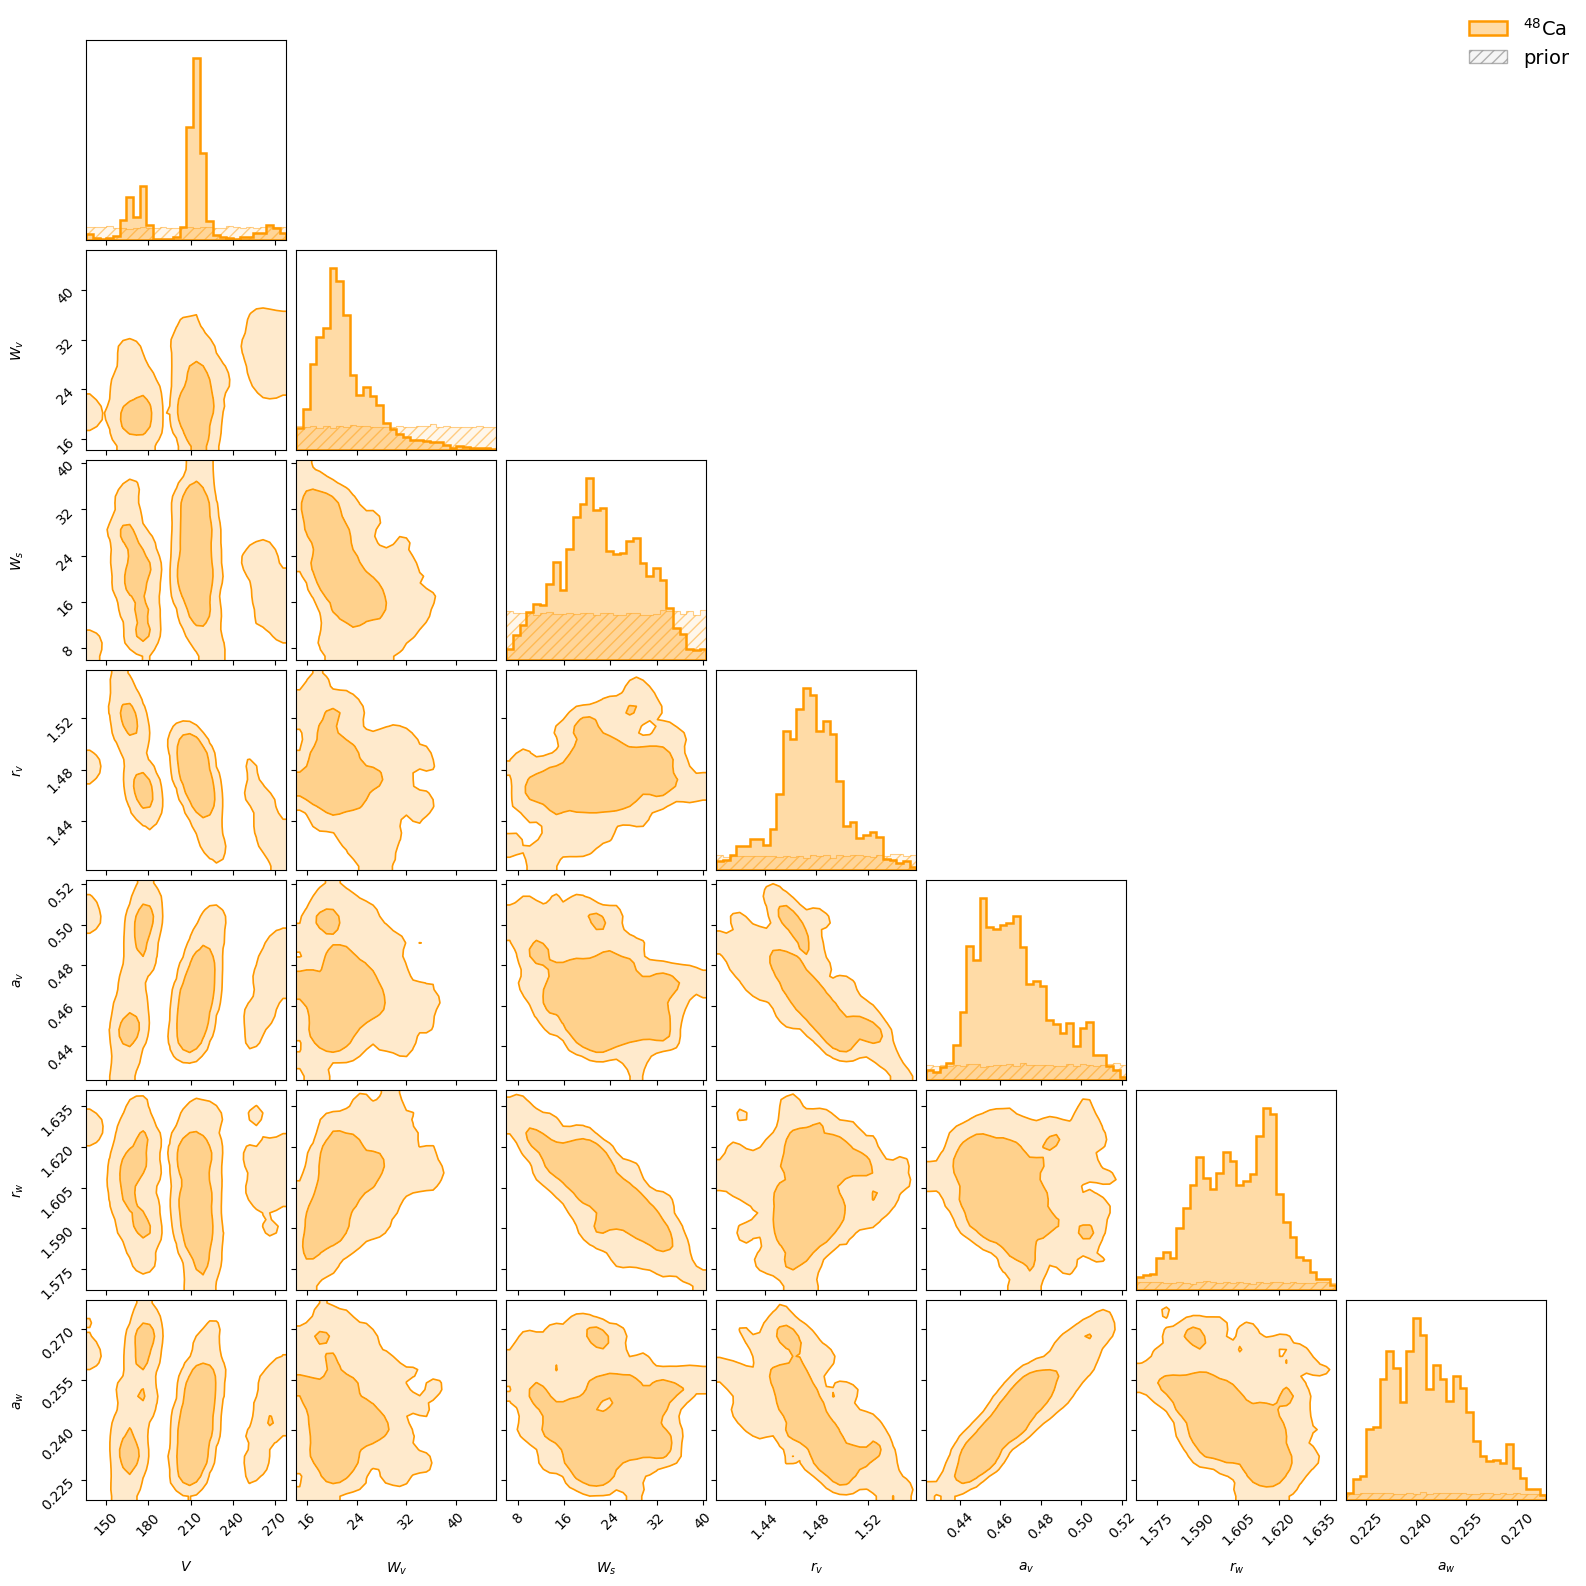

In [12]:
import corner
from matplotlib.colors import to_rgba
from matplotlib.patches import Patch


def corner_overlay(samples, labels, keys, priors=None, ranges=None, **kwargs):
    """Overlay corner plots for several data sets with a common range.

    Ranges are driven by the posteriors (central 99%), so the panels zoom in on
    them; `priors` (dict key -> (n, ndim) sample array) are drawn on the 1D panels
    only, as hatched histograms on the full-prior density scale - where the
    posterior is likelihood-dominated they appear as small, nearly flat slices.
    """
    if ranges is None:
        allsamples = np.vstack([samples[key] for key in keys])
        ranges = list(zip(np.percentile(allsamples, 0.5, axis=0), np.percentile(allsamples, 99.5, axis=0)))
    npanel = len(ranges)
    fig = None
    for key in keys:
        c = colors[key]
        fig = corner.corner(
            samples[key],
            labels=labels,
            color=c,
            fig=fig,
            range=ranges,
            bins=30,
            smooth=1.0,
            plot_datapoints=False,
            plot_density=False,
            levels=(0.68, 0.95),
            fill_contours=True,
            contourf_kwargs={"colors": [(0, 0, 0, 0), to_rgba(c, 0.2), to_rgba(c, 0.45)]},
            contour_kwargs={"colors": [to_rgba(c, 1.0)], "linewidths": 1.2},
            hist_kwargs={
                "density": True,
                "histtype": "stepfilled",
                "facecolor": to_rgba(c, 0.35),
                "edgecolor": to_rgba(c, 1.0),
                "linewidth": 1.8,
            },
            **kwargs,
        )
    if priors is not None:
        axes = np.array(fig.axes).reshape(npanel, npanel)
        for key in keys:
            c = colors[key]
            for i in range(npanel):
                draws = priors[key][:, i]
                lo, hi = ranges[i]
                counts, edges = np.histogram(draws, bins=30, range=(lo, hi))
                density = counts / (len(draws) * np.diff(edges))
                axes[i, i].stairs(
                    density, edges, fill=True,
                    facecolor=to_rgba(c, 0.08), edgecolor=to_rgba(c, 0.45),
                    hatch="///", linewidth=0.8,
                )
    handles = [
        Patch(facecolor=to_rgba(colors[key], 0.35), edgecolor=colors[key], linewidth=1.8, label=isotope_label[key])
        for key in keys
    ]
    if priors is not None:
        handles.append(Patch(facecolor=to_rgba("gray", 0.08), edgecolor=to_rgba("gray", 0.6), hatch="///", label="prior"))
    fig.legend(handles=handles, loc="upper right", fontsize=14, framealpha=0)
    return fig


n_prior_draws = 40000
prior_rng = np.random.default_rng(7)
omp_prior_draws = {
    key: np.column_stack([p.rvs(n_prior_draws, random_state=prior_rng) for p in omp_prior[key]])
    for key in targets
}

omp_samples = {key: posterior_samples[key][:, :n_omp] for key in targets}
fig = corner_overlay(omp_samples, labels, list(targets), priors=omp_prior_draws)
plt.show()

## Decomposing the posterior into modes

The modes are cleanly separated in $V$, so we can split the samples at the minima of a kernel density estimate of the marginal posterior of $V$, and summarize each family separately: its posterior mass (the probability, given data, prior, and model, that this family is the right one), its parameters, and its volume integrals per nucleon pair,

$$
\frac{J_U}{4A} = \frac{4\pi}{4A}\int_0^\infty U(r)\, r^2\, dr .
$$

In [13]:
from scipy.stats import gaussian_kde

from jitr.optical_potentials.potential_forms import woods_saxon_safe as ws, woods_saxon_prime_safe as wsp


def volume_integral_per_nucleon(samples, key):
    """(J_V + i J_W) / (4 A) [MeV fm^3] for each posterior sample."""
    A = targets[key][0]
    r = np.linspace(0, 20, 2000)
    out = np.zeros(len(samples), dtype=complex)
    for i, (Vv, Wv, Ws, rv, av, rw, aw) in enumerate(samples[:, :n_omp]):
        Rv = rv * A ** (1 / 3)
        Rw = rw * A ** (1 / 3)
        out[i] += np.trapezoid(Vv * ws(r, Rv, av) * r**2, r)
        out[i] += 1j * np.trapezoid((Wv * ws(r, Rw, aw) - Ws * (-4 * aw) * wsp(r, Rw, aw)) * r**2, r)
    return 4 * np.pi / (4 * A) * out


def summarize(samples):
    q = np.percentile(samples, [16, 50, 84], axis=0)
    return [f"{m:.3g} [{lo:.3g}, {hi:.3g}]" for lo, m, hi in q.T]


# split the samples at the local minima of a KDE of the V marginal
v_samples = posterior_samples["Ca48"][:, 0]
# smooth by at least ~5 MeV: genuine families are ~40 MeV apart, while
# finite-sampling noise fragments a single family into sub-MeV wiggles
bw = max(len(v_samples) ** (-0.2), 5.0 / np.std(v_samples))
kde = gaussian_kde(v_samples, bw_method=bw)
v_grid = np.linspace(v_samples.min(), v_samples.max(), 1000)
density = kde(v_grid)
is_valley = (density[1:-1] < density[:-2]) & (density[1:-1] < density[2:])
cuts = v_grid[1:-1][is_valley]
mode_index = np.digitize(v_samples, cuts)
mode_weights = np.array([np.mean(mode_index == m) for m in range(len(cuts) + 1)])
modes = [m for m in np.argsort(mode_weights)[::-1] if mode_weights[m] >= 0.01]
modes = sorted(modes, key=lambda m: np.median(v_samples[mode_index == m]))  # order by V
print(f"{len(modes)} modes hold at least 1% of the posterior mass (of {len(cuts) + 1} candidates)")

mode_samples = {m: posterior_samples["Ca48"][mode_index == m] for m in modes}
mode_jv = {m: volume_integral_per_nucleon(mode_samples[m], "Ca48") for m in modes}
mode_names = {m: f"mode {i} ({100 * mode_weights[m]:.0f}% tempered mass)" for i, m in enumerate(modes)}

# which family does the full (untempered) likelihood prefer? The sampler stored
# beta * log L for every point it visited, so divide beta back out and compare maxima
raw_mode_index = np.digitize(results["Ca48"].samples[:, 0], cuts)
best_logl = {m: results["Ca48"].logl[raw_mode_index == m].max() / beta_temper for m in modes}
delta_best_logl = {m: best_logl[m] - max(best_logl.values()) for m in modes}

pd.DataFrame(
    {
        mode_names[m]: summarize(
            np.column_stack([
                mode_samples[m][:, :n_omp],
                np.exp(mode_samples[m][:, n_omp:]),
                mode_jv[m].real,
                mode_jv[m].imag,
            ])
        ) + [f"{delta_best_logl[m]:.1f}"]
        for m in modes
    },
    index=names + [n.removeprefix("log_") for n in ERR_NAMES]
    + ["J_V/4A [MeV fm^3]", "J_W/4A [MeV fm^3]", "max log L - best (untempered)"],
)

4 modes hold at least 1% of the posterior mass (of 5 candidates)


,mode 0 (1% tempered mass),mode 1 (25% tempered mass),mode 2 (65% tempered mass),mode 3 (8% tempered mass)
Vv,"138 [135, 140]","171 [164, 178]","214 [210, 218]","267 [257, 274]"
Wv,"20.1 [19.4, 34.1]","20.1 [17.8, 23.6]","21.2 [17.9, 25.6]","28 [25.6, 34.5]"
Ws,"8.59 [7.69, 16.9]","20.7 [12.3, 27.6]","23.8 [17.3, 31.7]","18 [13, 23.7]"
rv,"1.48 [1.48, 1.54]","1.49 [1.46, 1.53]","1.48 [1.46, 1.49]","1.43 [1.42, 1.46]"
av,"0.503 [0.463, 0.511]","0.478 [0.445, 0.503]","0.463 [0.45, 0.477]","0.473 [0.454, 0.487]"
rw,"1.63 [1.61, 1.63]","1.61 [1.59, 1.62]","1.6 [1.59, 1.62]","1.61 [1.6, 1.62]"
aw,"0.262 [0.251, 0.273]","0.249 [0.231, 0.268]","0.241 [0.232, 0.253]","0.244 [0.233, 0.256]"
s,"0.482 [0.466, 0.555]","0.532 [0.486, 0.589]","0.503 [0.47, 0.558]","0.526 [0.497, 0.562]"
b,"0.0911 [0.081, 0.129]","0.136 [0.0709, 0.25]","0.138 [0.0899, 0.29]","0.128 [0.0735, 0.254]"
J_V/4A [MeV fm^3],"515 [505, 533]","637 [625, 654]","774 [761, 785]","893 [877, 910]"


The families are far apart in parameter space, but produce nearly the same cross section - that is what makes this a genuine discrete ambiguity rather than a poorly converged fit. Below, the marginal posterior of $V$ colored by mode, and the median model curve of each mode against the data.

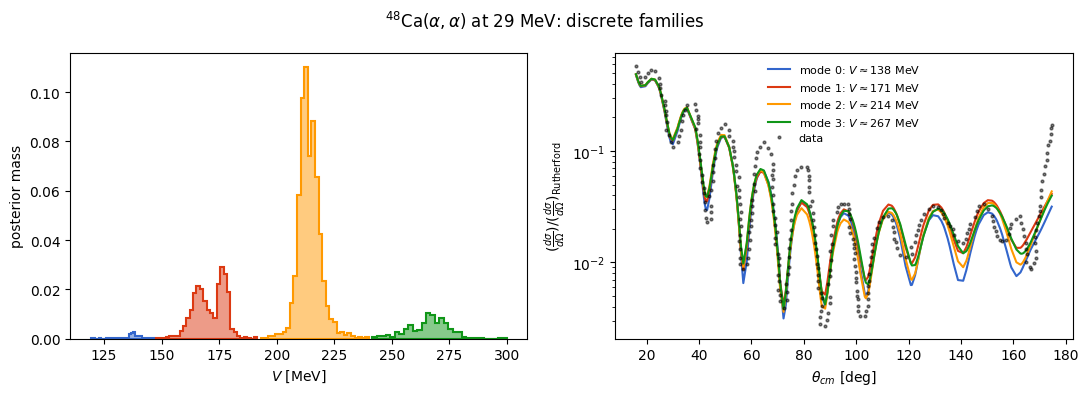

In [14]:
mode_colors = {m: c for m, c in zip(modes, ["#3366CC", "#DC3912", "#FF9900", "#109618", "#990099", "#0099C6"])}

fig, axes = plt.subplots(1, 2, figsize=(11, 4))
for i, m in enumerate(modes):
    axes[0].hist(
        mode_samples[m][:, 0], bins=30,
        weights=np.full(len(mode_samples[m]), 1.0 / len(v_samples)),
        facecolor=to_rgba(mode_colors[m], 0.5), edgecolor=mode_colors[m], linewidth=1.5, histtype="stepfilled",
    )
    theta_median = np.median(mode_samples[m][:, :n_omp], axis=0)
    axes[1].plot(
        data["Ca48"]["x"], calculate_xs_ratio(theta_median, "Ca48"),
        color=mode_colors[m], label=rf"mode {i}: $V \approx {theta_median[0]:.0f}$ MeV",
    )
axes[0].set_xlabel(r"$V$ [MeV]")
axes[0].set_ylabel("posterior mass")
axes[1].plot(data["Ca48"]["x"], data["Ca48"]["y"], ".", color="k", alpha=0.5, markersize=4, label="data")
axes[1].set_yscale("log")
axes[1].set_xlabel(r"$\theta_{cm}$ [deg]")
axes[1].set_ylabel(r"$(\frac{d\sigma}{d\Omega}) / (\frac{d\sigma}{d\Omega})_\text{Rutherford}$")
axes[1].legend(framealpha=0, fontsize=8)
fig.suptitle(r"$^{48}$Ca($\alpha,\alpha$) at 29 MeV: discrete families")
plt.tight_layout()
plt.show()

## How do the calibration conclusions hold up?

The data support a ladder of discrete families. With loose physical bounds, four modes survive, at $V \approx 138, 171, 214$ and $267$ MeV - spaced by the characteristic $\sim 40$-$50$ MeV of the node-count ambiguity, with real volume integrals climbing in steps of $\sim 120$ MeV fm$^3$. Their cross sections are nearly degenerate over most of the angular range and separate only at the most backward angles, which is precisely what makes this an ambiguity: no amount of forward-angle data will resolve it.

The family selected in the calibration notebook is the one the data prefer. The $V \approx 214$ window carries both the largest tempered mass (65%) and the highest untempered best-fit likelihood - the runner-up at $V \approx 171$ sits $\sim 4$ units of log-likelihood lower, $V \approx 267$ sits $\sim 7$ lower, and $V \approx 138$ is out of the running. So the prior choice made there - selecting the deep family near $V \approx 205$ - agrees with what a much more expensive, wide-open search recovers.

Two caveats keep us honest. First, everything above is a property of the *tempered* posterior: at $\beta = 1$ the weights would concentrate even more strongly onto the preferred family, and each island would sharpen. Second, within each $V$ window the continuous $V$-$r_v$ ambiguity is broad at $T=4$, so the per-mode medians - the geometries and volume integrals especially - locate the tempered mass along that ridge, not the sharp $\beta = 1$ posterior. For the precise answer *within* the preferred family, use the calibration notebook; this notebook's job is the map, and it costs a few minutes rather than hours.